In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.shape

(37249, 2)

In [5]:
df.sample()['clean_comment'].values

array(['most the boycott comments seem from the bjp side general public doesn really care about the thing right '],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [7]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [8]:
df[df['clean_comment'].isna()]['category'].value_counts()


,count
category,
0,100


In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(350)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [14]:
df=df[~(df['clean_comment'].str.strip()=='')]

In [15]:
#convert the clean_comment column to lowercase
df['clean_comment']=df['clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [16]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [17]:
#remove trailing amd leading whitespace from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.strip()

#verify the transportation by checking for any remaining trailing whitespace
df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [18]:
#identity commentd containing urls
url_pattern=r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls=df[df['clean_comment'].str.contains(url_pattern,regex=True)]
comments_with_urls.head()

,clean_comment,category


In [19]:
#identity comments containing new line characters
comments_with_newline=df[df['clean_comment'].str.contains('\n')]
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [20]:
#remove new line characters from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)
#verify the transformation by checking for any remaining new lines
comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


EDA

<Axes: xlabel='category', ylabel='count'>

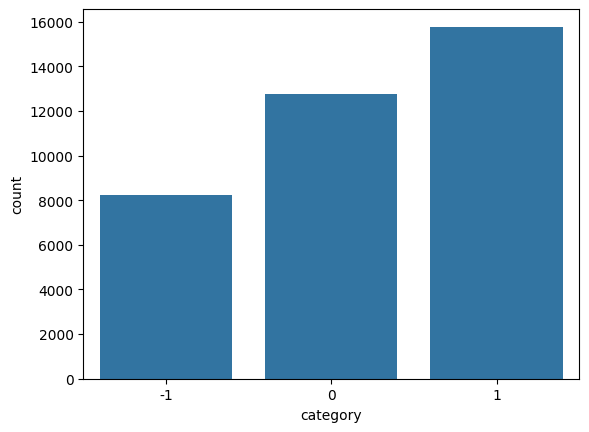

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
# distribution of classes
sns.countplot(data=df,x='category')


In [22]:
# frequency distribution of sentiments (in percentage)
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.71
-1,22.42


In [23]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))
df.sample(5)

,clean_comment,category,word_count
23772,what makes you guys happy,1,5
12299,probably know really less about usa even thoug...,1,35
34747,bjp brought citizenship bill but congress part...,-1,68
13148,anyone else having guinness wild turkey americ...,-1,17
14316,consider most indians pretty based least the i...,1,34


In [24]:
df['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


/tmp/ipykernel_13464/2898084430.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['word_count'],kde=True)


<Axes: xlabel='word_count', ylabel='Density'>

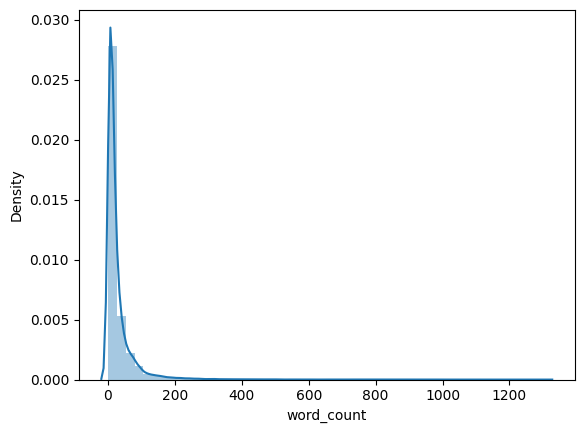

In [25]:
sns.distplot(df['word_count'],kde=True)

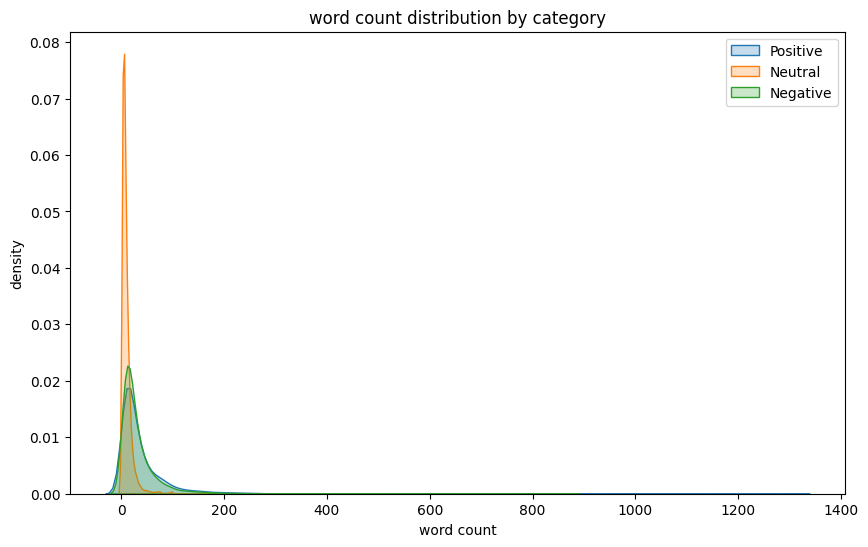

In [26]:
# create the figure and axes
plt.figure(figsize=(10,6))
#plot KDE for category 1
sns.kdeplot(df[df['category']==1]['word_count'],label='Positive',fill=True)
#plot KDE for category 0
sns.kdeplot(df[df['category']==0]['word_count'],label='Neutral',fill=True)
#plot KDE for category -1
sns.kdeplot(df[df['category']==-1]['word_count'],label='Negative',fill=True)

#add title and label
plt.title('word count distribution by category')
plt.xlabel('word count')
plt.ylabel('density')

#add legend
plt.legend()
# show the plot
plt.show()

<Axes: ylabel='word_count'>

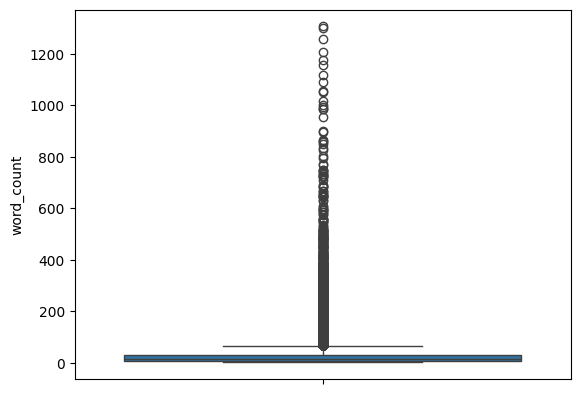

In [27]:
sns.boxplot(df['word_count'])

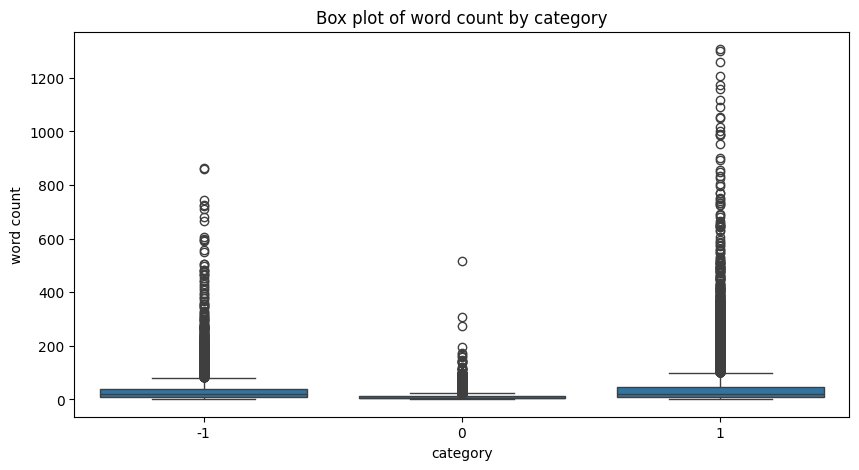

In [28]:
# create a boxplot for the 'wordcout' column categorized by 'category'
plt.figure(figsize=(10,5))
sns.boxplot(x='category',y='word_count',data=df)
plt.title('Box plot of word count by category')
plt.xlabel('category')
plt.ylabel('word count')
plt.show()

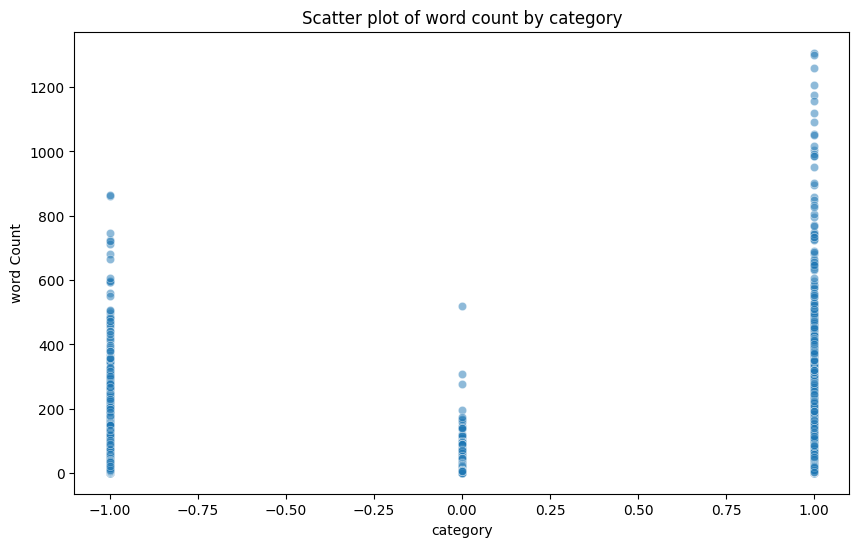

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='category',y='word_count',alpha=0.5)
plt.title('Scatter plot of word count by category')
plt.xlabel('category')
plt.ylabel('word Count')
plt.show()
#

<Axes: xlabel='category', ylabel='word_count'>

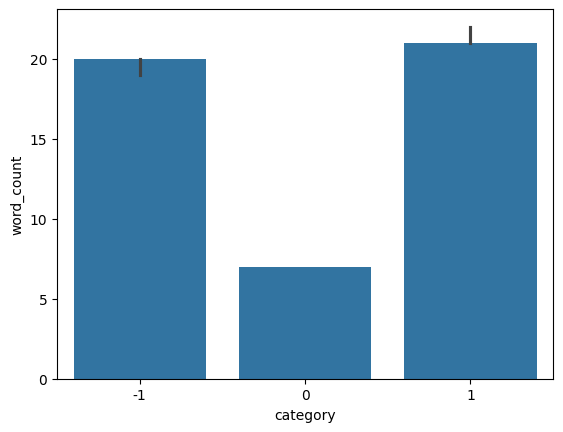

In [30]:
sns.barplot(df,x='category',y='word_count',estimator='median')

In [31]:
!pip install nltk

In [32]:
from nltk.corpus import stopwords
# import NLTK sstopword if not already download
import nltk
nltk.download('stopwords')
# definen the list of english stopwords
stop_words=set(stopwords.words('english'))
#create a new column 'num_stop_words' by counting the number of stopwords in each column
df['num_stop_words']=df['clean_comment'].apply(lambda x:len([word for word in x.split() if word in stop_words]))

df.sample(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_comment,category,word_count,num_stop_words
26117,people who bought mesa prime access should com...,0,17,6
6196,basically people have instilled their hope mod...,1,22,6
17993,foreign hand qljcmuj0qck,-1,3,0
26386,meri company leadership bhi pre submitted vett...,0,11,0
11351,thats impressive,1,2,0


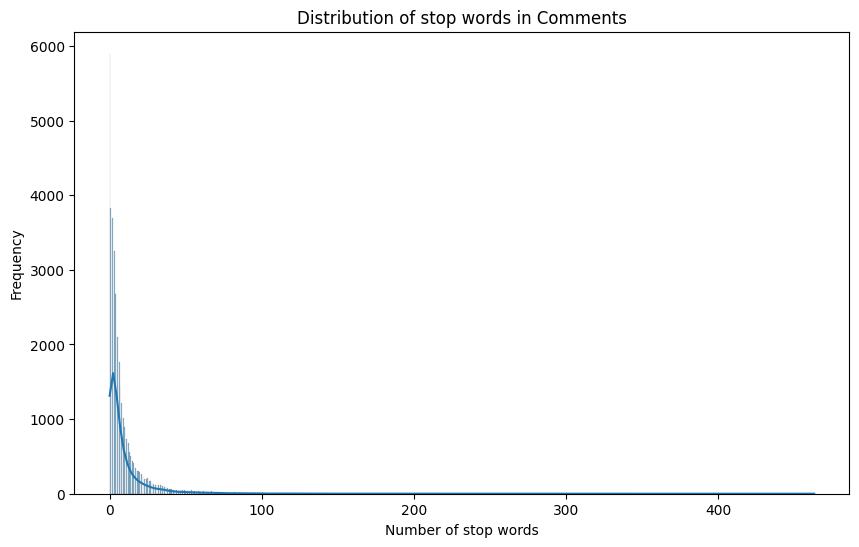

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(df['num_stop_words'],kde=True)
plt.title('Distribution of stop words in Comments')
plt.xlabel('Number of stop words')
plt.ylabel('Frequency')
plt.show()

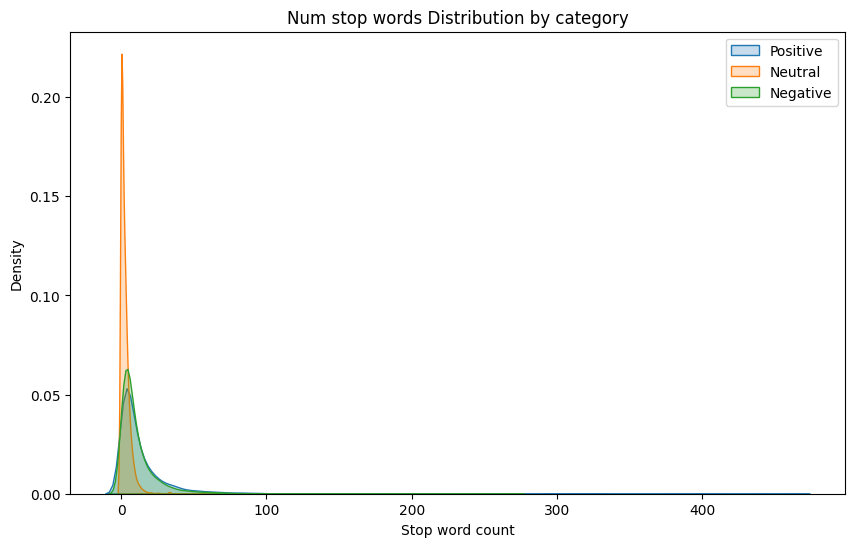

In [35]:
# create the figure and axes
plt.figure(figsize=(10,6))
#plot KDE for category 1
sns.kdeplot(df[df['category']==1]['num_stop_words'],label='Positive',fill=True)
#plot KDE for category 0
sns.kdeplot(df[df['category']==0]['num_stop_words'],label='Neutral',fill=True)
#plot kde for category -1
sns.kdeplot(df[df['category']==-1]['num_stop_words'],label='Negative',fill=True)

# add title and labels
plt.title('Num stop words Distribution by category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

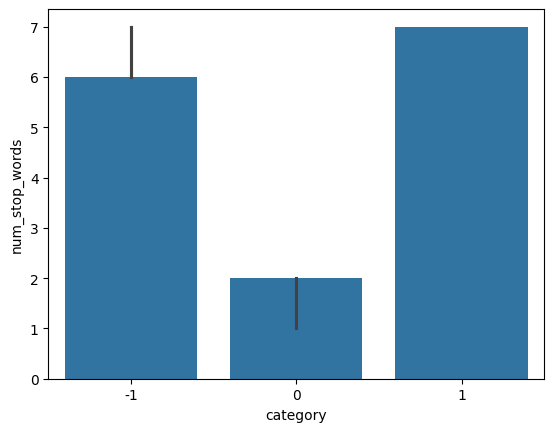

In [39]:
sns.barplot(df,x='category',y='num_stop_words',estimator='median')

/tmp/ipykernel_13464/888150390.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df,x='stop_word',y='count',palette='viridis')


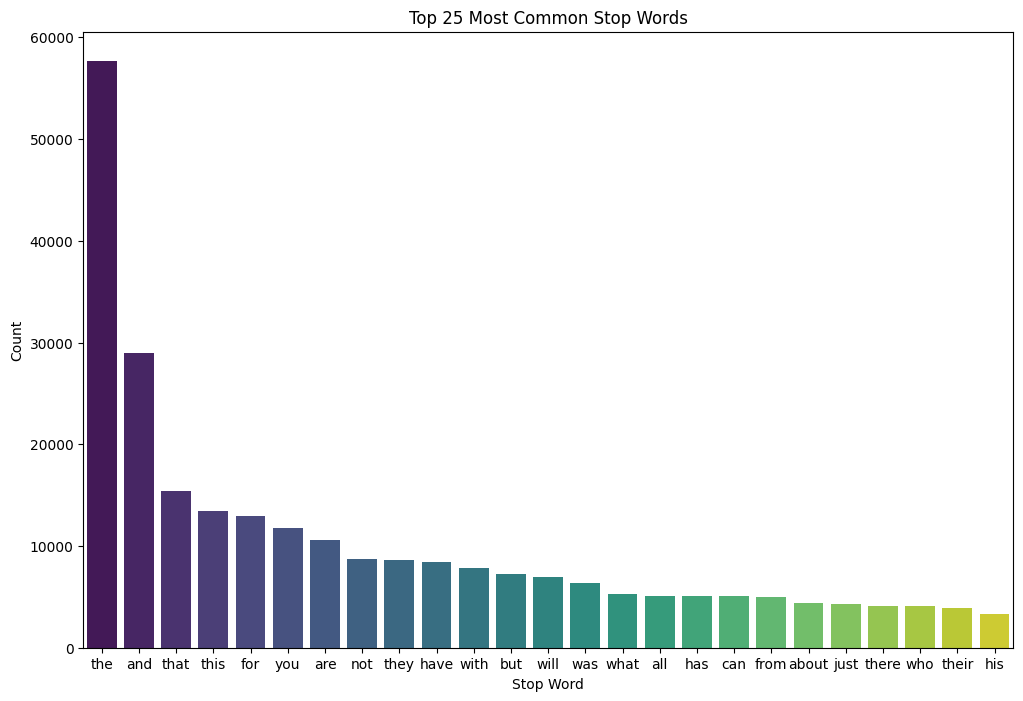

In [41]:
from collections import Counter
all_stop_words=[word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]
most_common_stop_words=Counter(all_stop_words).most_common(25)
top_25_df=pd.DataFrame(most_common_stop_words,columns=['stop_word','count'])
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='stop_word',y='count',palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Stop Word')
plt.ylabel('Count')
plt.show()

In [42]:
df['num_chars']=df['clean_comment'].apply(len)
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [43]:
df['num_chars'].describe()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [45]:
from collections import Counter
import pandas as pd

all_text = ' '.join(df['clean_comment'])
char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(
    char_frequency.items(),
    columns=['character', 'frequency']
).sort_values(by='frequency', ascending=False)

In [46]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '段', '她', '谁'], dtype=object)

In [47]:
char_frequency_df.tail(50)

,character,frequency
1286,货,1
1287,语,1
1312,耐,1
1313,精,1
342,━,1
345,⊂,1
346,゜,1
347,ｊ,1
1289,显,1
1291,鞋,1


In [48]:
# create a new column 'num_punctuation_chars' to count the punctutation character in each comment
df['num_punctuation_chars']=df['clean_comment'].apply(lambda x:len([char for char in x if char in '.,!?;:"\'()[]{}-']))
df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
14518,the handshake was required the hug was straigh...,1,21,9,115,0
31280,very human,0,2,1,10,0
32874,very sad that karachi bakery had put this sign...,-1,20,7,117,0
11000,dosto apko youtube par video upload karna hai ...,0,13,0,77,0
31379,liberals are cancer india fighting get rid thi...,0,9,2,54,0


In [49]:
df['num_punctuation_chars'].describe()

,num_punctuation_chars
count,36793.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


/tmp/ipykernel_13464/787530124.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='magma')


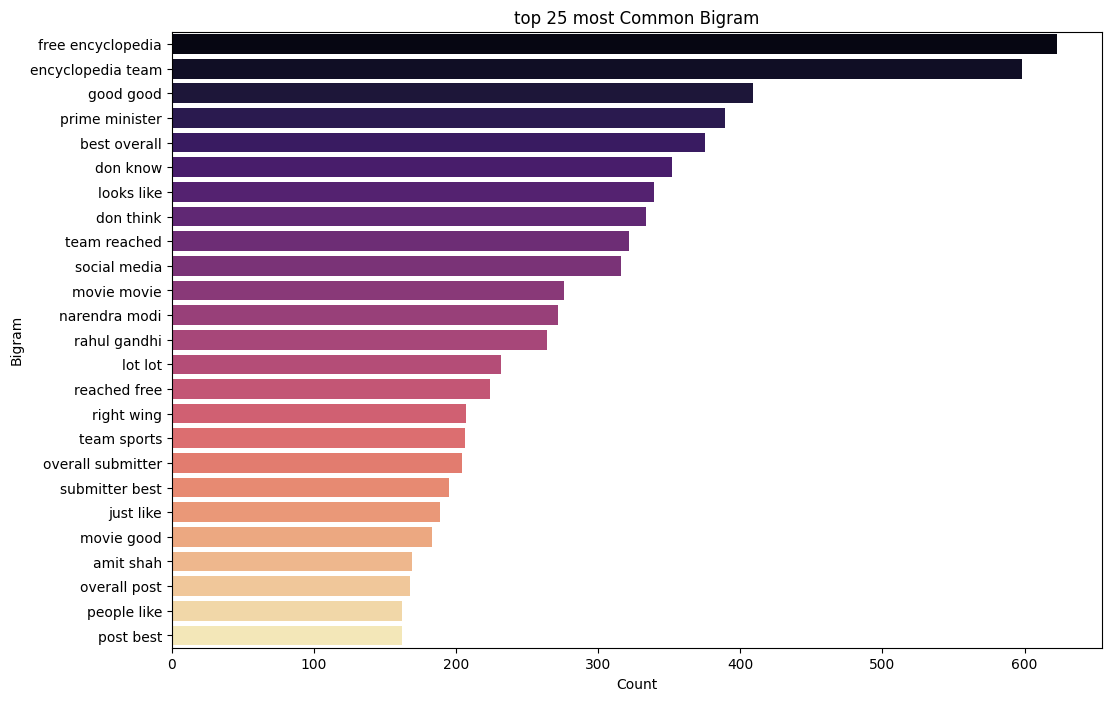

In [52]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_ngrams(corpus,n=None):
    vec=CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
    bag_of_words=vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq,key=lambda x:x[1],reverse=True)
    return words_freq[:n]
  # get the top 25 bigram
top_25_bigrams=get_top_ngrams(df['clean_comment'],25)
top_25_bigrams_df=pd.DataFrame(top_25_bigrams,columns=['bigram','count'])
# plot the countplot for the 25 bigram
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='magma')
plt.title('top 25 most Common Bigram')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


/tmp/ipykernel_13464/1192663046.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


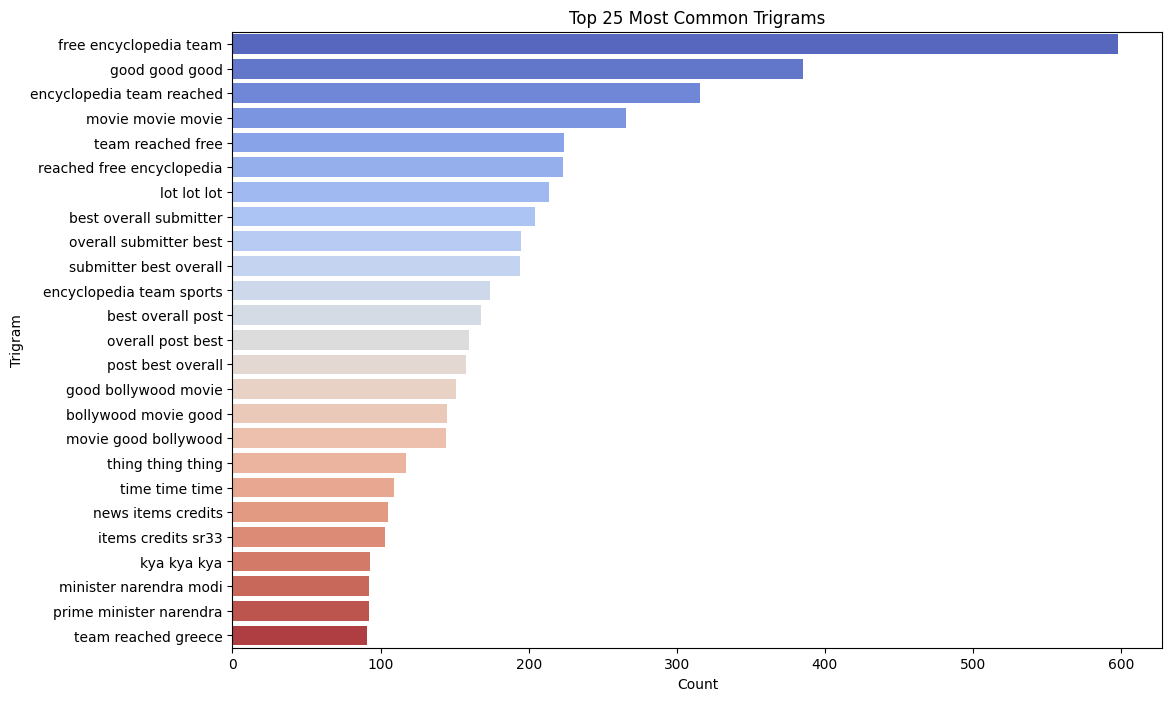

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3,3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)

    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:n]

# get top 25 trigrams
top_25_trigrams = get_top_ngrams(df['clean_comment'], 25)

top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# plot
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')

plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')

plt.show()

In [54]:
#remove non-english characters from the 'clean_comment' column
# keep only standard englsih letters, digit and common puntuation
import re

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x))
)

In [55]:
all_text=' '.join(df['clean_comment'])
# count the frequency of each character
char_frequency=Counter(all_text)
# create a dataframe from the character frequency
char_frequency_df=pd.DataFrame(
    char_frequency.items(),
    columns=['character','frequency']
).sort_values(by='frequency',ascending=False)
char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [56]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [57]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))-{'not','but','however','no','yet'}
df['clean_comment']=df['clean_comment'].apply(lambda x:' '.join([word for word in x.split() if word not in stop_words]))

In [58]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [60]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
#define the lemmatizer
lemmatizer=WordNetLemmatizer()
# apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment']=df['clean_comment'].apply(lambda x:' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


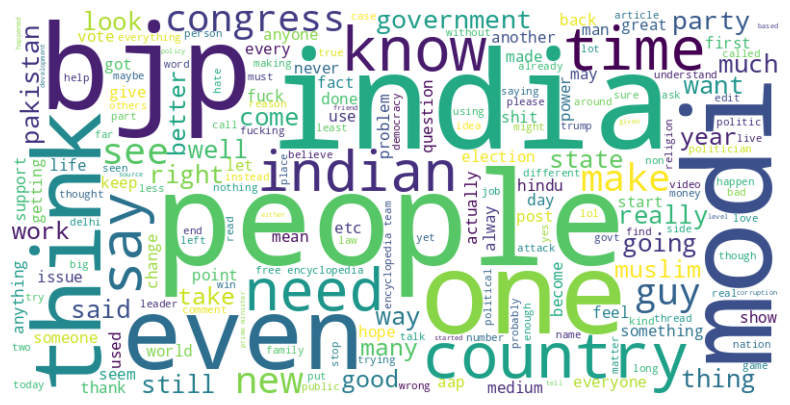

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def plot_word_cloud(text):
  wordcloud=WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()
plot_word_cloud(df['clean_comment'])

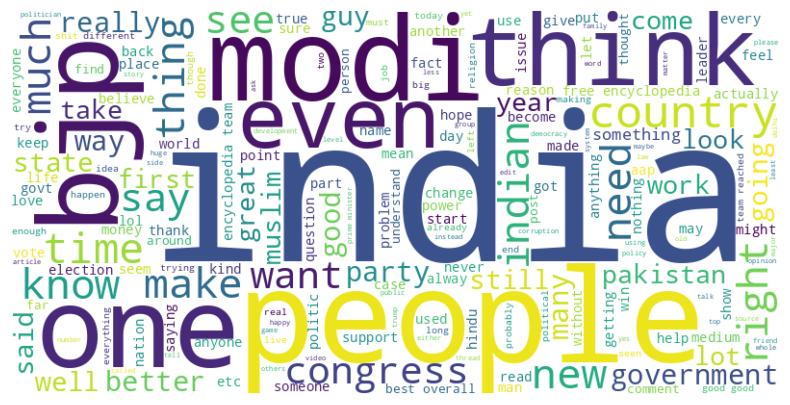

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def plot_word_cloud(text):
  wordcloud=WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()
plot_word_cloud(df[df['category']==1]['clean_comment'])

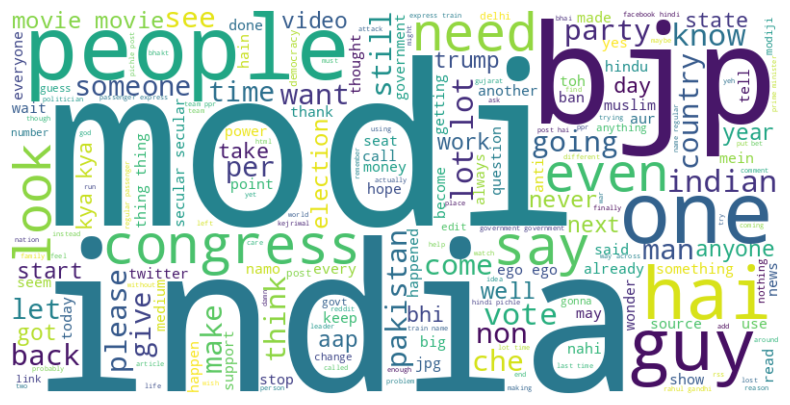

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def plot_word_cloud(text):
  wordcloud=WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()
plot_word_cloud(df[df['category']==0]['clean_comment'])

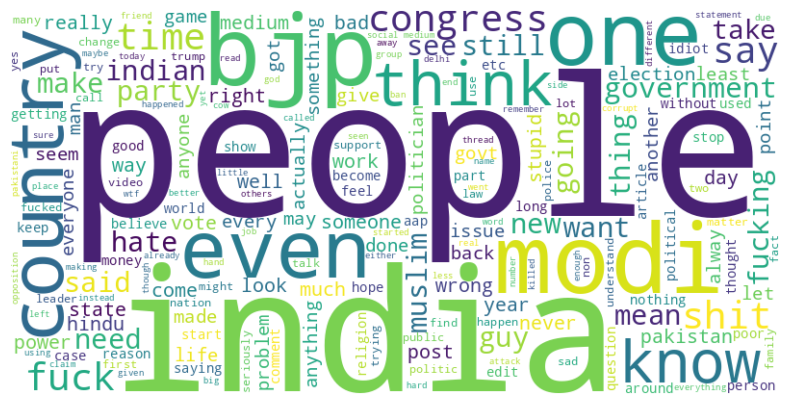

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
def plot_word_cloud(text):
  wordcloud=WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()
plot_word_cloud(df[df['category']==-1]['clean_comment'])

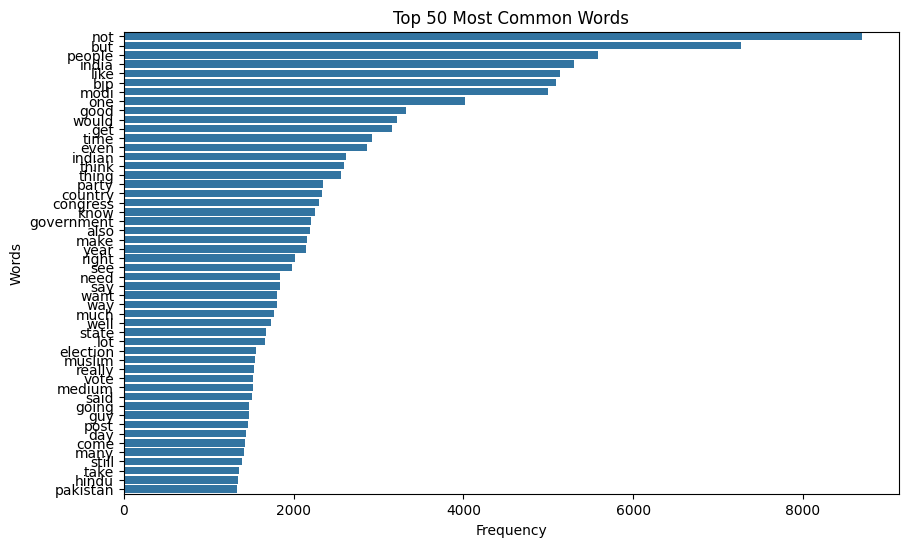

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_top_n_words(df, n=20):
    """Plot the top N most common words in the dataset."""

    # flatten all words
    words = ' '.join(df['clean_comment']).split()

    # get most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # split words and counts
    words, counts = zip(*most_common_words)

    # plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Common Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=50)

In [70]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot top N words with stacked bars by sentiment category."""

    word_category_counts = defaultdict(lambda: {-1: 0, 0: 0, 1: 0})

    # Count words per category
    for _, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']

        for word in words:
            word_category_counts[word][category] += 1

    # Total counts
    total_word_counts = {
        word: sum(counts.values())
        for word, counts in word_category_counts.items()
    }

    # Sort words
    most_common_words = sorted(
        total_word_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )[start:start+n]

    top_words = [word for word, _ in most_common_words]

    # Get category-wise counts
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot
    plt.figure(figsize=(12, 8))

    plt.barh(top_words, negative_counts, color='red', label='Negative (-1)')
    plt.barh(top_words, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)')
    plt.barh(
        top_words,
        positive_counts,
        left=[i + j for i, j in zip(negative_counts, neutral_counts)],
        color='green',
        label='Positive (1)'
    )

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Words by Sentiment Category')

    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

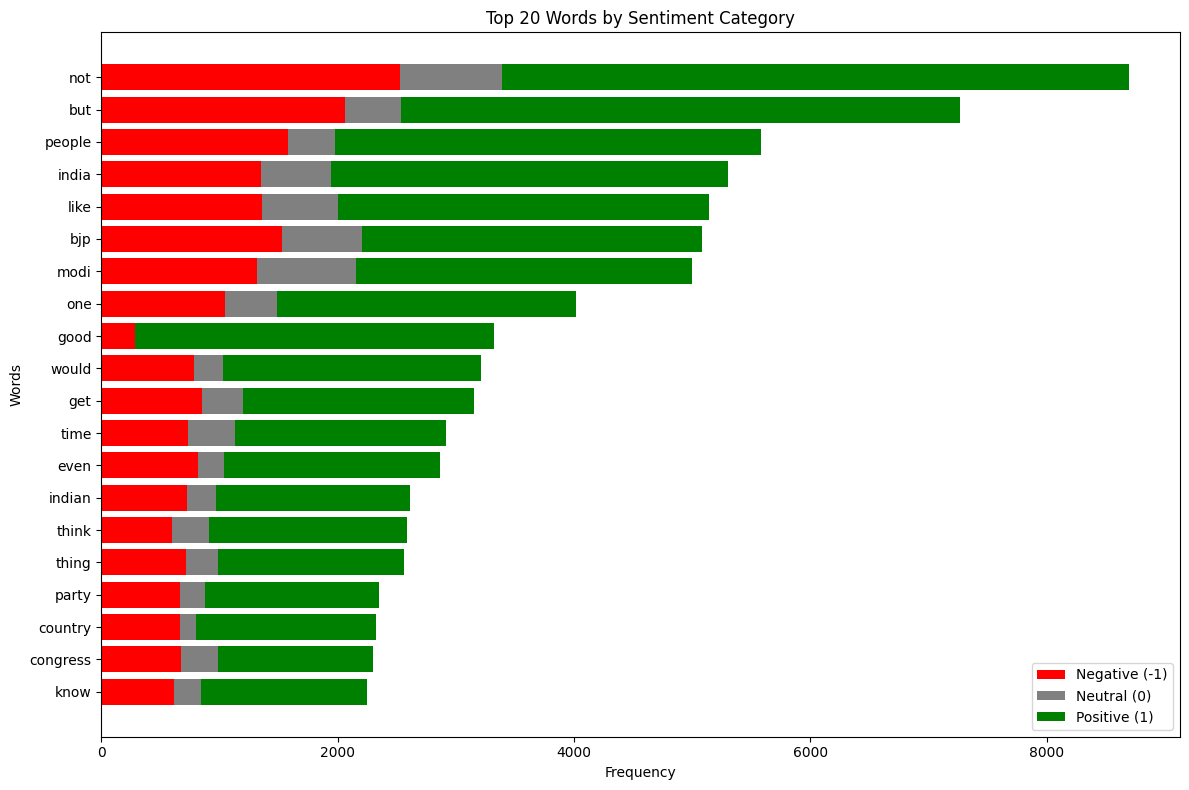

In [71]:
plot_top_n_words_by_category(df, n=20)